# Bidirectional Conversion Between Inspired CO₂ Fraction and Arterial CO₂ Partial Pressure
### A ventilation-aware Technical Note 

---

**Abstract** 

The majority of Carbon-dioxide challenges are reported either as an inspired fraction ($F_iCO_2$, %) or arterial/end-tidal partial pressure ($P_aCO_2 \approx P_{ET}CO_2$, mmHg or kPa), but these measures are not directly proportional because hypercapnia stimulates ventilation, thereby offsetting part of the inspired CO₂ load. 

This note reconstructs the alveolar CO₂ mass balance with an explicit inspired term, couples it to a fairly "linear" hypercapnic ventilatory response, and reduces the system to a single governing equation that admits closed-form solutions in both directions. 

The derivation is presented alongside the corresponding calculations for transparency, with all constants referenced.

## 1. Theory: Physiological Framework

The dependence of alveolar gas composition on ventilation is one of the foundational results
of respiratory physiology. The model developed here builds on a few classical principles,
beginning with the definition of alveolar ventilation itself.

**(a) Alveolar Ventilation and Dead Space.** 

Not all inspired gas reaches the alveoli. Each tidal breath ($V_T$) divides into the volume that fills the conducting airways —
the anatomic dead space ($V_D$), which takes no part in gas exchange — and the volume that
reaches the respiratory zone ($V_A$):

$$V_T = V_D + V_A. \qquad (1)$$

Multiplying each volume by the respiratory frequency $f$ converts these to per-minute flows
(a dot denotes a rate, e.g. $\dot V_A = V_A \cdot f$), so the total (minute) ventilation is the
sum of alveolar and dead-space ventilation:

$$\dot V_E = \dot V_A + \dot V_D, \qquad \text{equivalently} \qquad \dot V_A = \dot V_E - \dot V_D. \qquad (2)$$

Only $\dot V_A$ ventilates the gas-exchanging alveoli and therefore sets alveolar CO₂. With a
typical $V_T = 500$ mL, $V_D = 150$ mL and $f = 12$ min⁻¹, the minute ventilation is
$\dot V_E = 500 \cdot 12 = 6000$ mL·min⁻¹, whereas the alveolar ventilation is
$\dot V_A = (500 - 150) \cdot 12 = 4200$ mL·min⁻¹ $\approx 4.2$ L·min⁻¹ (West & Luks, 2021).
This resting value is the one adopted when no baseline PaCO₂ is available (Step 1).

**(b) Ventilation determines alveolar CO₂.** 

Haldane and Priestley (1905) demonstrated that
alveolar CO₂ is tightly regulated and that ventilation is driven primarily by CO₂ changes. Under
steady-state conditions, metabolic CO₂ production ($\dot V_{CO_2}$) is balanced by pulmonary
elimination, such that the alveolar CO₂ fraction ($F_ACO_2$) equals CO₂ output divided by
alveolar ventilation ($\dot V_A$):

$$F_ACO_2 = \frac{\dot V_{CO_2}}{\dot V_A}. \qquad (3)$$

**(c) The ideal alveolar compartment.** 

Riley and Cournand (1949) introduced the concept of a
single, well-mixed *ideal alveolar air* in which, for healthy lungs, arterial and end-tidal
tensions equal the alveolar value, $P_aCO_2 \approx P_ACO_2 \approx P_{ET}CO_2$ — the same
premise that underlies contemporary end-tidal targeting (Slessarev et al., 2007).

**(d) From fraction to partial pressure.** 

By Dalton's law of partial pressures (Dalton,
1802), each species exerts a pressure equal to its fraction multiplied by the total dry-gas
pressure; in humidified alveolar gas at 37 °C the water-vapour pressure ($P_{H_2O} = 47$ mmHg)
is first subtracted, giving $P_ACO_2 = F_ACO_2 \cdot (P_{atm} - P_{H_2O})$. Applying this to
Eq. (3) yields the classical alveolar ventilation equation (West, 2012; Lumb & Thomas, 2020):

$$P_ACO_2 = \frac{K \cdot \dot V_{CO_2}}{\dot V_A}, \qquad K = 0.863. \qquad (4)$$

The factor $K$ is a unit constant only: $\dot V_{CO_2}$ is conventionally reported at STPD and
$\dot V_A$ at BTPS, and $K = \dfrac{310}{273} \cdot \dfrac{760}{1000} = 0.863$ carries the
temperature and pressure corrections (Cruickshank & Hirschauer, 2004; West, 2012).

Equation (4) was formulated for carbon-dioxide-free inspirate and for a *fixed* alveolar
ventilation. A CO₂ challenge violates both premises. Sections 2.1–2.4 reinstate the inspired
term and the ventilatory response, and solve the resulting relationship in closed form.

In [1]:
# Eq. (4): the classical alveolar ventilation equation, CO2-free inspirate.
K, VCO2 = 0.863, 200.0        # unit constant; CO2 output, mL/min STPD
VA = 4.3                       # resting alveolar ventilation, L/min BTPS
PACO2 = K * VCO2 / VA          # mmHg
print(f'PACO2 = K*VCO2/VA = {K}*{VCO2}/{VA} = {PACO2:.1f} mmHg   (normocapnic ~40)')

PACO2 = K*VCO2/VA = 0.863*200.0/4.3 = 40.1 mmHg   (normocapnic ~40)


## 2. Model Derivation: The conversion, step by step

Each step below states the reasoning and equation, then evaluates it immediately.

### 2.1 **Step 1** — Baseline alveolar ventilation 

The model is anchored to the subject's normocapnic state. Rearranging Eq. (4) gives the baseline alveolar ventilation directly from the baseline arterial CO₂ tension:

$$\dot V_{A,\text{base}} = \frac{K \cdot \dot V_{CO_2}}{P_aCO_{2,\text{base}}}. \qquad (5)$$

For $\dot V_{CO_2} = 200$ mL·min⁻¹ and $P_aCO_{2,\text{base}} = 40$ mmHg this is $\approx$ 4.3 L·min⁻¹,
the accepted resting value (West & Luks, 2021; Lumb & Thomas, 2020). Anchoring in this way renders
the mapping self-consistent: at $F_iCO_2 = 0$ it returns the baseline exactly. Where the
baseline is not reported, $P_aCO_{2,\text{base}} = 40$ mmHg is assumed together with the
literature resting value $\dot V_{A,\text{base}} = 4.2$ L·min⁻¹ (West & Luks, 2021; Lumb & Thomas,
2020); the ventilatory feedback of Step 3 absorbs the small resulting inconsistency.

In [3]:
# Eq. (5): baseline alveolar ventilation from the baseline PaCO2.
PaCO2_base = 40.0                              # mmHg, normocapnic baseline
VA_base = K * VCO2 / PaCO2_base                # L/min BTPS
print(f'VA_base = K*VCO2/PaCO2_base = {K}*{VCO2}/{PaCO2_base:.0f} = {VA_base:.3f} L/min')

VA_base = K*VCO2/PaCO2_base = 0.863*200.0/40 = 4.315 L/min


### 2.2 **Step 2** — Inclusion of inspired CO₂

When inspired gas contains CO₂, the alveolar mass balance acquires an additional inspired
term (Slessarev et al., 2007),

$$F_ACO_2 = F_iCO_2 + \frac{\dot V_{CO_2}}{\dot V_A}. \qquad (6)$$

By Dalton's law, each gas fraction corresponds to a partial pressure through the dry-gas
pressure $(P_{atm} - P_{H_2O})$; for the inspired term,

$$P_iCO_2 = F_iCO_2 \cdot (P_{atm} - P_{H_2O}).$$

Substituting Dalton's law into Eq. (6) and expressing every term as a partial pressure gives

$$P_ACO_2 = P_iCO_2 + \frac{K \cdot \dot V_{CO_2}}{\dot V_A}. \qquad (7)$$

Evaluated with ventilation fixed at its baseline value, Eq. (7) provides a feedback-free
prediction of arterial CO₂. Because it neglects the ventilatory response to hypercapnia, it
substantially overestimates the resulting arterial tension, motivating the introduction of
physiological feedback in the next step.

In [4]:
# Eq. (7): alveolar CO2 with an inspired term, ventilation held at baseline.
Patm, PH2O = 760.0, 47.0
Pdry = Patm - PH2O                             # dry-gas pressure, 713 mmHg
FiCO2 = 0.05                                   # inspired fraction, 5%
PICO2 = FiCO2 * Pdry                           # inspired partial pressure, mmHg
PACO2_nofeedback = PICO2 + K * VCO2 / VA_base  # VA fixed at baseline
print(f'PICO2               = FiCO2*(Patm-PH2O) = {PICO2:.1f} mmHg')
print(f'PACO2 (no feedback) = {PACO2_nofeedback:.1f} mmHg   <- overestimate; see Step 3')

PICO2               = FiCO2*(Patm-PH2O) = 35.6 mmHg
PACO2 (no feedback) = 75.7 mmHg   <- overestimate; see Step 3


### 2.3 **Step 3** — Hypercapnic ventilatory response

Alveolar ventilation increases as arterial CO₂ rises. Over the approximately linear
physiological range (≈ 40–80 mmHg), this response can be represented by a simple linear
relationship with slope $S$ (Read, 1967; Hirshman et al., 1975; West, 2012; West & Luks, 2021),

$$\dot V_A(P_aCO_2) = \dot V_{A,\text{base}} + S \cdot (P_aCO_2 - P_aCO_{2,\text{base}}). \qquad (8)$$

The model adopts the population-mean response slope, $S = 2.69$ L·min⁻¹·mmHg⁻¹ (Hirshman et
al., 1975), which lies within the range reported by Read (1967) and is consistent with the
classic textbook estimate that ventilation rises by about 2–3 L·min⁻¹ for each 1 mmHg rise in
$P_{CO_2}$ (West, 2012; West & Luks, 2021). Although this value provides a representative
population estimate, substantial inter-individual variability remains and constitutes the
principal source of uncertainty. Its effect on the conversion is examined in Section 5.

In [5]:
# Eq. (8): CO2-sensitive alveolar ventilation.
S = 2.69                                       # HCVR slope, L/min/mmHg
def VA_of(paco2):
    return VA_base + S * (paco2 - PaCO2_base)
for paco2 in (40.0, 45.0, 60.0):
    print(f'PaCO2 {paco2:5.1f} mmHg  ->  VA = {VA_of(paco2):6.2f} L/min')

PaCO2  40.0 mmHg  ->  VA =   4.31 L/min
PaCO2  45.0 mmHg  ->  VA =  17.77 L/min
PaCO2  60.0 mmHg  ->  VA =  58.11 L/min


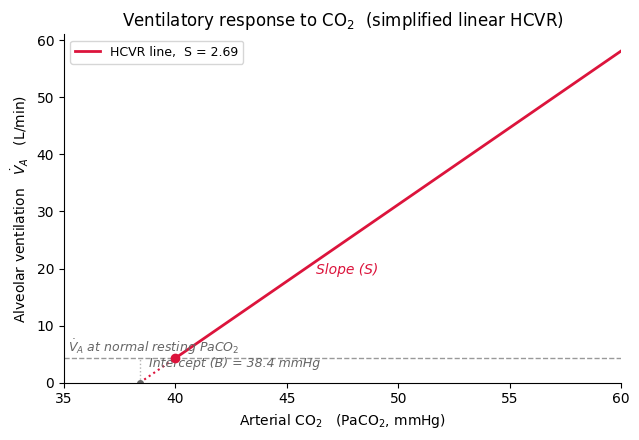

In [6]:
# Visualise Step 3: how alveolar ventilation rises with PaCO2 (simplified linear HCVR, S = 2.69).
# Solid = region actually used (PaCO2 >= baseline); dotted = extrapolation below baseline, whose
# x-intercept B is the apnoeic threshold; dashed line = ventilation at the normal resting PaCO2.
try:
    import numpy as np, matplotlib.pyplot as plt

    B = PaCO2_base - VA_base / S                  # x-intercept of the HCVR line (apnoeic threshold)
    x_used   = np.linspace(PaCO2_base, 60, 70)    # region actually used (PaCO2 >= baseline)
    x_extrap = np.linspace(B, PaCO2_base, 20)     # extrapolation down to the intercept B

    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    # horizontal asymptote: ventilation at the normal resting PaCO2
    ax.axhline(VA_base, ls='--', color='0.6', lw=1)
    ax.text(35.2, VA_base + 1.0, r'$\dot{V}_A$ at normal resting PaCO$_2$',
            color='0.4', fontsize=9, style='italic')

    # HCVR line: solid where used, dotted where extrapolated below baseline
    ax.plot(x_used, VA_of(x_used), color='crimson', lw=2, label=f'HCVR line,  S = {S}')
    ax.plot(x_extrap, VA_of(x_extrap), color='crimson', lw=1.5, ls=':')

    # intercept B: vertical dotted guide + marker on the axis
    ax.plot([B, B], [0, VA_base], ls=':', color='0.7', lw=1)
    ax.plot([B], [0], marker='o', color='0.4', ms=4)
    ax.annotate(f'Intercept (B) = {B:.1f} mmHg', xy=(B, 0), xytext=(B + 0.4, 2.8),
                color='0.4', fontsize=9, style='italic')

    # baseline operating point + slope label
    ax.plot([PaCO2_base], [VA_base], 'o', color='crimson', ms=6, zorder=5)
    ax.text(46.3, VA_of(45.5), 'Slope (S)', color='crimson', fontsize=10, style='italic')

    ax.set_xlim(35, 60); ax.set_ylim(0, None)
    ax.set_xlabel('Arterial CO$_2$   (PaCO$_2$, mmHg)')
    ax.set_ylabel(r'Alveolar ventilation   $\dot{V}_A$   (L/min)')
    ax.set_title('Ventilatory response to CO$_2$  (simplified linear HCVR)')
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout(); plt.show()
except ImportError:
    print('matplotlib/numpy not installed - run:  pip install matplotlib numpy')

### 2.4 **Step 4** — Governing equation

Substituting the CO₂-dependent ventilation, Eq. (8), into the alveolar mass balance (Eq. (7)), with with the approximation $P_aCO_2 \approx P_ACO_2$, yields a single governing equation,

$$P_aCO_2 = F_iCO_2 \cdot (P_{atm} - P_{H_2O}) + \frac{K \cdot \dot V_{CO_2}}{\dot V_{A,\text{base}} + S \cdot (P_aCO_2 - P_aCO_{2,\text{base}})}. \qquad (9)$$

This equation admits closed-form solution in both directions.

#### 2.4.1 **Forward direction ($P_aCO_2 \rightarrow F_iCO_2$)** 

The inspired fraction follows directly,

$$F_iCO_2 = \frac{P_aCO_2 - K \cdot \dot V_{CO_2} / \dot V_A(P_aCO_2)}{P_{atm} - P_{H_2O}}. \qquad (10)$$

#### 2.4.2 **Reverse direction ($F_iCO_2 \rightarrow P_aCO_2$)** 

The dependence of ventilation on arterial CO₂ makes Eq. (9) quadratic in $P_aCO_2$. Because the ventilatory response is linear, the physically meaningful solution is obtained analytically from the upper root, eliminating the need for numerical iteration:

$$P_aCO_2 = \frac{(S \cdot P_iCO_2 - D) + \sqrt{(S \cdot P_iCO_2 - D)^2 + 4 \cdot S \cdot (P_iCO_2 \cdot D + K \cdot \dot V_{CO_2})}}{2 \cdot S}, \qquad (11)$$

where $D \equiv \dot V_{A,\text{base}} - S \cdot P_aCO_{2,\text{base}}$.

The reference implementation evaluates both roots below. With the feedback restored, the 5%
inspired challenge that Step 2 mapped to ≈ 76 mmHg resolves to ≈ 45 mmHg, and the forward
solution recovers the original fraction (round-trip check).

In [7]:
from fico2_paco2_converter import (
    params_from_baseline, fico2_to_paco2, paco2_to_fico2, mmhg_to_kpa,
)

p = params_from_baseline(40.0)                 # Step 1 anchoring, VA_base self-consistent
pa = fico2_to_paco2(5.0, p)                    # reverse: Eq. (11)
fi = paco2_to_fico2(pa, p)                     # forward: Eq. (10), round-trip
print(f'FiCO2 5.00 %  ->  PaCO2 = {pa:.2f} mmHg = {mmhg_to_kpa(pa):.2f} kPa')
print(f'PaCO2 {pa:.2f} mmHg  ->  FiCO2 = {fi:.2f} %   (recovers input)')

FiCO2 5.00 %  ->  PaCO2 = 45.15 mmHg = 6.02 kPa
PaCO2 45.15 mmHg  ->  FiCO2 = 5.00 %   (recovers input)


## 3. Using the converter

The implementation below provides the bidirectional conversion derived in Section 2. After specifying the required inputs, execute the corresponding cell to estimate either the inspired CO₂ fraction or the resulting arterial CO₂ tension.


**Forward conversion — $P_aCO_2 \rightarrow F_iCO_2$.** 

Specify the target arterial (or end-tidal) CO₂ tension together with the baseline state. The baseline alveolar ventilation is computed from Eq. (5), and Eq. (10) returns the inspired CO₂ fraction required to achieve the target.

In [8]:
paco2_target = 60.0   # mmHg, hypercapnic level to reach
paco2_base   = 40.0   # mmHg, normocapnic baseline

p = params_from_baseline(paco2_base)
fico2 = paco2_to_fico2(paco2_target, p)
print(f'VA_base = {p.VA_base:.3f} L/min ;  VA(target) = {p.VA(paco2_target):.3f} L/min')
print(f'PaCO2 {paco2_target:.1f} mmHg  ->  FiCO2 = {fico2:.3f} %'      f'   (PICO2 = {fico2/100*p.Pdry:.1f} mmHg)')

VA_base = 4.315 L/min ;  VA(target) = 58.115 L/min
PaCO2 60.0 mmHg  ->  FiCO2 = 7.999 %   (PICO2 = 57.0 mmHg)


**Reverse conversion — $F_iCO_2 \rightarrow P_aCO_2$.** 

If the baseline is known, set it; otherwise leave `paco2_base = None` for the literature resting fallback
($P_aCO_{2,\text{base}} = 40$ mmHg, $\dot V_{A,\text{base}} = 4.2$ L·min⁻¹). The reverse
solution uses the closed form, Eq. (11).

In [9]:
from fico2_paco2_converter import params_resting_default

fico2_percent = 10.0    # inspired CO2, %
paco2_base    = None   # mmHg, or 'None' if unknown -> resting fallback

if paco2_base is None:
    p = params_resting_default()
    tag = f'resting fallback (base={p.PaCO2_base:.0f} mmHg, VA_base={p.VA_base:.1f} L/min)'
else:
    p = params_from_baseline(paco2_base)
    tag = f'baseline known (base={p.PaCO2_base:.0f} mmHg, VA_base={p.VA_base:.3f} L/min)'

pa = fico2_to_paco2(fico2_percent, p)
print(f'mode: {tag}')
print(f'FiCO2 {fico2_percent:.2f} %  ->  PaCO2 = {pa:.2f} mmHg = {mmhg_to_kpa(pa):.3f} kPa'      f'   ({pa - p.PaCO2_base:+.2f} mmHg from baseline)')

mode: resting fallback (base=40 mmHg, VA_base=4.2 L/min)
FiCO2 10.00 %  ->  PaCO2 = 73.15 mmHg = 9.752 kPa   (+33.15 mmHg from baseline)


## 4. Reference values

Steady-state $P_aCO_2$ for a fixed inspired CO₂ at sea level (baseline 40 mmHg, $S = 2.69$).

In [10]:
p = params_from_baseline(40.0)
print(f"{'FiCO2 %':>8} {'PICO2 mmHg':>11} {'PaCO2 mmHg':>11} {'PaCO2 kPa':>10}")
for fi in (0, 2, 5, 7, 8):
    pa = fico2_to_paco2(fi, p)
    print(f'{fi:8.0f} {fi/100*p.Pdry:11.1f} {pa:11.2f} {mmhg_to_kpa(pa):10.2f}')

 FiCO2 %  PICO2 mmHg  PaCO2 mmHg  PaCO2 kPa
       0         0.0       40.00       5.33
       2        14.3       40.81       5.44
       5        35.6       45.15       6.02
       7        49.9       54.02       7.20
       8        57.0       60.01       8.00


## 5. Uncertainty from the ventilatory response

The single largest source of uncertainty in the conversion is the ventilatory response itself —
both its **magnitude** (the slope $S$) and its **time course**.

### 5.1 Inter-individual variability in the slope $S$

$S$ is treated here as a fixed population value, but it varies widely between individuals.
Hirshman et al. (1975) report a mean of 2.69 L·min⁻¹·mmHg⁻¹ with a range of 1.16–5.95, and
Read (1967) reports individual rebreathing slopes spanning roughly 2–4. The table and figure
below map a fixed inspired challenge across this range, quantifying how strongly the estimated
PaCO₂ depends on the assumed slope.

In [11]:
fico2 = 5.0
print(f'FiCO2 = {fico2}% , baseline 40 mmHg\n')
print(f"{'S':>6} {'PaCO2 mmHg':>11}")
for S in (1.16, 1.96, 2.69, 4.04, 5.95):
    p = params_from_baseline(40.0, S=S)
    print(f'{S:6.2f} {fico2_to_paco2(fico2, p):11.2f}')

FiCO2 = 5.0% , baseline 40 mmHg

     S  PaCO2 mmHg
  1.16       48.17
  1.96       46.17
  2.69       45.15
  4.04       44.03
  5.95       43.15


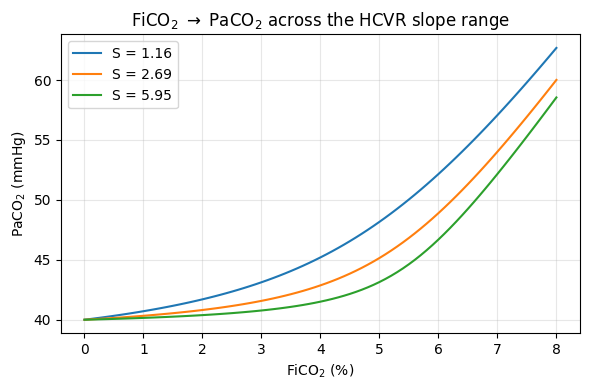

In [12]:
# Optional figure (requires matplotlib): FiCO2 -> PaCO2 across a range of S.
try:
    import numpy as np, matplotlib.pyplot as plt
    grid = np.linspace(0, 8, 81)
    plt.figure(figsize=(6, 4))
    for S in (1.16, 2.69, 5.95):
        p = params_from_baseline(40.0, S=S)
        plt.plot(grid, [fico2_to_paco2(f, p) for f in grid], label=f'S = {S}')
    plt.xlabel('FiCO$_2$ (%)'); plt.ylabel('PaCO$_2$ (mmHg)')
    plt.title('FiCO$_2$ $\\rightarrow$ PaCO$_2$ across the HCVR slope range')
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
except ImportError:
    print('matplotlib not installed - skipping figure (pip install matplotlib)')

### 5.2 Time dependence of the response, and the two-threshold structure

The conversion is a **steady-state** relationship: Eq. (9) assumes the ventilatory response to
the imposed CO₂ has fully developed. In reality, with inspired CO₂ held fixed the response
unfolds over time in components with distinct dynamics. The acute response has a **fast
component** (carotid bodies; time constant ≈ 8–26 s, 12–30% of the response) and a **slower
central component** (medullary chemoreceptors; ≈ 65–180 s, 70–88%) (Bellville et al., 1979;
Tansley et al., 1998). Ventilation does not reach an acute plateau, however: it continues to rise
over tens of minutes (Khamnei & Robbins, 1990), and a **third, slow component** develops over hours
as acclimatisation (Tansley et al., 1998; Gelfand & Lambertsen, 1973). Consistent with this, Schaefer
(1958) found that breathing ≈ 7.5% CO₂ roughly doubled respiratory rate and minute volume over
the first ~10–15 min.

**Consequence for the conversion.** Because the converter returns the *fully compensated*
(equilibrium) PaCO₂, it applies once the fast and central components are complete — i.e. after
the first few minutes of a sustained challenge, the regime of most BOLD-MRI and cerebrovascular-
reactivity protocols. In the first tens of seconds after a step increase in $F_iCO_2$, ventilation
has not yet risen and the true PaCO₂ is transiently **higher** than the steady-state estimate; it
then falls toward equilibrium as the fast → central components engage, and drifts slightly lower
again over hours as acclimatisation adds further ventilation. The converter therefore gives an
equilibrium estimate, not the transient peak.

**Two thresholds underlie the single slope.** The two acute components map onto the two-breakpoint
"dogleg" resolved by steady-state and rebreathing methods: a **peripheral-chemoreflex threshold**
(≈ 41 mmHg PCO₂) and a slightly higher **central-chemoreflex threshold** (≈ 45 mmHg) (Mohan &
Duffin, 1997; see also Pedersen et al., 1999). Below the peripheral threshold ventilation is
nearly flat; between the thresholds only the peripheral reflex contributes (a shallow slope);
above the central threshold both operate and the response steepens. The single fixed slope $S$
used here is a linear approximation to this combined suprathreshold response.

**Upper limit.** The linear rise cannot continue indefinitely — at very high PaCO₂ the response
plateaus and then fails (CO₂ narcosis, cardiovascular collapse) — so the model is restricted to
the approximately linear working range (≈ 40–80 mmHg).

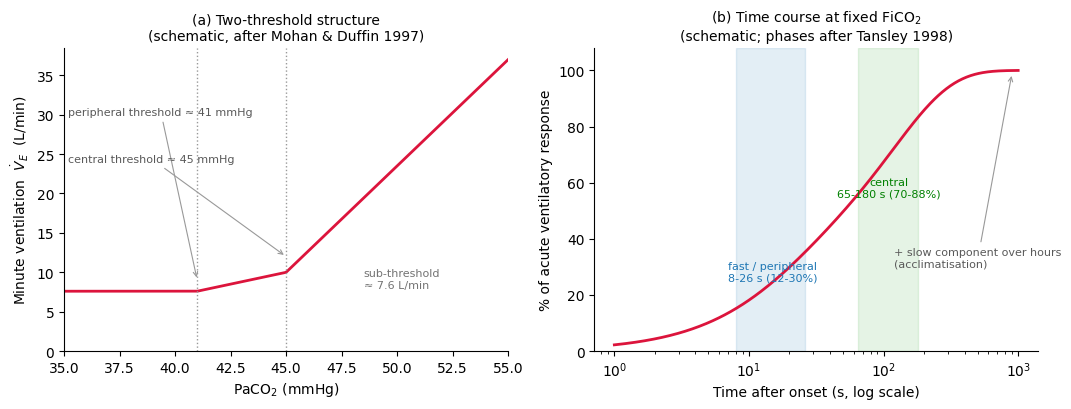

In [13]:
# Section 5.2 schematic (ORIGINAL figure; concepts/parameters cited in the note below).
# (a) two-threshold "dogleg" of the HCVR (after Mohan & Duffin, 1997);
# (b) time course of the response at fixed FiCO2 (phase parameters after Tansley et al., 1998).
try:
    import numpy as np, matplotlib.pyplot as plt

    fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 4.2))

    # (a) two-threshold dogleg: minute ventilation vs PaCO2
    Vsub, Tp, Tc, sp, sc = 7.6, 41.0, 45.0, 0.6, 2.7   # sub-threshold VE; thresholds; illustrative slopes
    x = np.linspace(35, 55, 400)
    V = np.where(x < Tp, Vsub, np.where(x < Tc, Vsub + sp*(x-Tp), Vsub + sp*(Tc-Tp) + sc*(x-Tc)))
    axA.plot(x, V, color='crimson', lw=2)
    for T in (Tp, Tc):
        axA.axvline(T, ls=':', color='0.6', lw=1)
    axA.annotate('peripheral threshold ≈ 41 mmHg', xy=(Tp, 9), xytext=(35.2, 30),
                 fontsize=8, color='0.35', arrowprops=dict(arrowstyle='->', color='0.6', lw=0.8))
    axA.annotate('central threshold ≈ 45 mmHg', xy=(Tc, 12), xytext=(35.2, 24),
                 fontsize=8, color='0.35', arrowprops=dict(arrowstyle='->', color='0.6', lw=0.8))
    axA.text(48.5, 8, 'sub-threshold\n≈ 7.6 L/min', fontsize=8, color='0.45')
    axA.set_xlabel('PaCO$_2$ (mmHg)'); axA.set_ylabel(r'Minute ventilation  $\dot V_E$  (L/min)')
    axA.set_title('(a) Two-threshold structure\n(schematic, after Mohan & Duffin 1997)', fontsize=10)
    axA.set_xlim(35, 55); axA.set_ylim(0, None)
    for s in ('top', 'right'):
        axA.spines[s].set_visible(False)

    # (b) time course of the ventilatory response at fixed FiCO2 (fast + central components)
    t = np.logspace(0, 3, 400)                                     # 1 s -> ~17 min
    resp = 100*(0.25*(1-np.exp(-t/15)) + 0.75*(1-np.exp(-t/120)))  # -> acute steady state
    axB.axvspan(8, 26, color='tab:blue', alpha=0.12)
    axB.axvspan(65, 180, color='tab:green', alpha=0.12)
    axB.plot(t, resp, color='crimson', lw=2)
    axB.set_xscale('log')
    axB.annotate('fast / peripheral\n8-26 s (12-30%)', xy=(15, 25), fontsize=8, color='tab:blue', ha='center')
    axB.annotate('central\n65-180 s (70-88%)', xy=(110, 55), fontsize=8, color='green', ha='center')
    axB.annotate('+ slow component over hours\n(acclimatisation)', xy=(900, 99), xytext=(120, 30),
                 fontsize=8, color='0.35', arrowprops=dict(arrowstyle='->', color='0.6', lw=0.8))
    axB.set_xlabel('Time after onset (s, log scale)'); axB.set_ylabel('% of acute ventilatory response')
    axB.set_title('(b) Time course at fixed FiCO$_2$\n(schematic; phases after Tansley 1998)', fontsize=10)
    axB.set_ylim(0, 108)
    for s in ('top', 'right'):
        axB.spines[s].set_visible(False)

    plt.tight_layout(); plt.show()
except ImportError:
    print('matplotlib/numpy not installed - run:  pip install matplotlib numpy')

*Figure note.* Both panels are **original schematics** prepared for this note. The
underlying concepts and parameters are attributed to Mohan & Duffin (1997) (two-threshold
structure, panel a) and Tansley et al. (1998) (response phases, panel b); they are **not**
reproductions or adaptations of any published figure.

## 6. Time-resolved converter (Model B)

Model A assumes the ventilatory response has fully developed (steady state). **Model B adds one
variable — the challenge duration $t$** — because the response is not instantaneous. It does *not*
extend the dose range: for humans it is used only up to PaCO₂ ≈ 80 mmHg (full derivation in §11 of the
technical note).

The response develops with a **fast** (peripheral, $\tau_1 \approx 15$ s; Cunningham et al. 1986;
Swanson & Bellville 1975) and a **slow** (central, $\tau_2 \approx 130$ s; Bellville et al. 1979; Dahan
et al. 1990) component, the fast one contributing $f \approx 0.20$ (Tansley et al. 1998):

$$\phi(t) = f\,(1-e^{-t/\tau_1}) + (1-f)\,(1-e^{-t/\tau_2}), \qquad S_{\mathrm{eff}}(t) = \phi(t)\cdot S$$

The effective slope grows from 0 to $S$ over the first ~5–10 min. For a fixed $t$ the model is linear in
PaCO₂, so it is **still closed-form** (Model A with $S \rightarrow S_{\mathrm{eff}}(t)$). The slope $S$
itself spans ~1–6 L·min⁻¹·mmHg⁻¹ across studies/methods and is adjustable (default 2.69).

In [14]:
from fico2_paco2_converter import ParamsB, fico2_to_paco2_B, paco2_to_fico2_B

pB = ParamsB()
print('Effective slope S_eff(t) = phi(t) * S   (steady-state S = 2.69):')
for t in (10, 30, 60, 120, 300, None):
    lab = 'steady' if t is None else f'{t:>4} s'
    print(f'  t = {lab}:  phi = {pB.phi(float("inf") if t is None else t):.3f}  ->  S_eff = {pB.S_eff(t):.2f}')

print('\nPaCO2 from a fixed 7% challenge, by duration (transiently higher early):')
for t in (10, 60, 300, None):
    lab = 'steady' if t is None else f'{t:>4} s'
    print(f'  t = {lab}:  PaCO2 = {fico2_to_paco2_B(7, pB, t_s=t):.1f} mmHg')

print('\nSlope S is adjustable (reported range ~1-6 L/min/mmHg):')
for s in (1.5, 2.69, 4.0):
    print(f'  S = {s}:  5% CO2 (steady) -> PaCO2 = {fico2_to_paco2_B(5, ParamsB(S=s)):.1f} mmHg')

Effective slope S_eff(t) = phi(t) * S   (steady-state S = 2.69):
  t =   10 s:  phi = 0.157  ->  S_eff = 0.42
  t =   30 s:  phi = 0.338  ->  S_eff = 0.91
  t =   60 s:  phi = 0.492  ->  S_eff = 1.32
  t =  120 s:  phi = 0.682  ->  S_eff = 1.83
  t =  300 s:  phi = 0.920  ->  S_eff = 2.48
  t = steady:  phi = 1.000  ->  S_eff = 2.69

PaCO2 from a fixed 7% challenge, by duration (transiently higher early):
  t =   10 s:  PaCO2 = 62.4 mmHg
  t =   60 s:  PaCO2 = 56.5 mmHg
  t =  300 s:  PaCO2 = 54.3 mmHg
  t = steady:  PaCO2 = 54.0 mmHg

Slope S is adjustable (reported range ~1-6 L/min/mmHg):
  S = 1.5:  5% CO2 (steady) -> PaCO2 = 47.1 mmHg
  S = 2.69:  5% CO2 (steady) -> PaCO2 = 45.1 mmHg
  S = 4.0:  5% CO2 (steady) -> PaCO2 = 44.1 mmHg


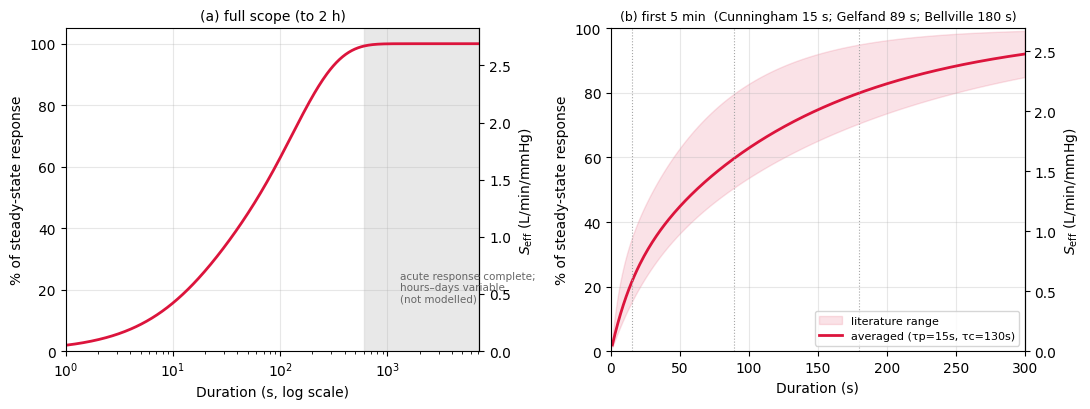

In [15]:
# Ventilatory response vs duration, built from reported time constants (full scope + 5-min zoom).
try:
    import numpy as np, matplotlib.pyplot as plt
    S, f, tp, tc = 2.69, 0.20, 15.0, 130.0
    def phi(t, a=tp, b=tc): return f*(1-np.exp(-t/a)) + (1-f)*(1-np.exp(-t/b))
    fig, (axF, axZ) = plt.subplots(1, 2, figsize=(11, 4.2))
    t = np.logspace(0, np.log10(7200), 400)                       # (a) full scope, 1 s -> 2 h
    axF.plot(t, 100*phi(t), color='crimson', lw=2)
    axF.axvspan(600, 7200, color='0.85', alpha=.6, zorder=0)
    axF.text(1300, 16, 'acute response complete;\nhours–days variable\n(not modelled)', fontsize=7.5, color='0.4')
    axF.set_xscale('log'); axF.set_xlim(1, 7200); axF.set_ylim(0, 105)
    axF.set_xlabel('Duration (s, log scale)'); axF.set_ylabel('% of steady-state response')
    axF.set_title('(a) full scope (to 2 h)', fontsize=10)
    tz = np.linspace(1, 300, 300)                                 # (b) first 5 min
    axZ.fill_between(tz, 100*phi(tz,6,65), 100*phi(tz,26,180), color='crimson', alpha=.12, label='literature range')
    axZ.plot(tz, 100*phi(tz), color='crimson', lw=2, label=f'averaged (τp={tp:.0f}s, τc={tc:.0f}s)')
    for xt in (15, 89, 180):
        axZ.axvline(xt, ls=':', color='0.65', lw=.8)
    axZ.set_xlim(0, 300); axZ.set_ylim(0, 100)
    axZ.set_xlabel('Duration (s)'); axZ.set_ylabel('% of steady-state response')
    axZ.set_title('(b) first 5 min  (Cunningham 15 s; Gelfand 89 s; Bellville 180 s)', fontsize=9)
    axZ.legend(fontsize=8, loc='lower right')
    for ax in (axF, axZ):
        ax.grid(alpha=.3)
        ax.secondary_yaxis('right', functions=(lambda y: y/100*S, lambda s: s/S*100)).set_ylabel(r'$S_{\rm eff}$ (L/min/mmHg)')
    plt.tight_layout(); plt.show()
except ImportError:
    print('matplotlib not installed - run:  pip install matplotlib numpy')

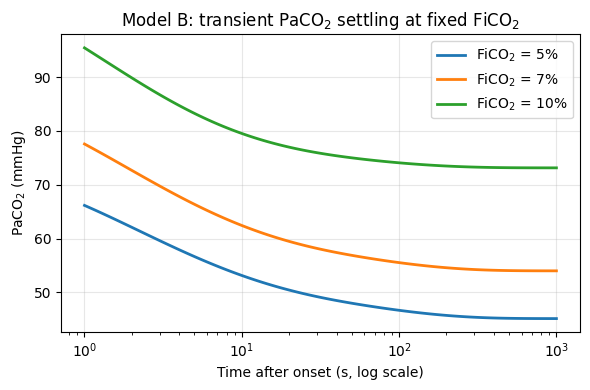

In [16]:
# PaCO2 vs time at fixed FiCO2 (Model B): transient overshoot settling to steady state.
try:
    import numpy as np, matplotlib.pyplot as plt
    ts = np.logspace(0, 3, 120)                       # 1 s -> ~17 min
    plt.figure(figsize=(6, 4))
    for fi in (5, 7, 10):
        plt.plot(ts, [fico2_to_paco2_B(fi, pB, t_s=t) for t in ts], lw=2, label=f'FiCO$_2$ = {fi}%')
    plt.xscale('log')
    plt.xlabel('Time after onset (s, log scale)'); plt.ylabel('PaCO$_2$ (mmHg)')
    plt.title('Model B: transient PaCO$_2$ settling at fixed FiCO$_2$')
    plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()
except ImportError:
    print('matplotlib not installed - run:  pip install matplotlib numpy')

## 7. Validation against reported CO₂ challenges

Overlaying the converter on paired *(inspired %, measured PaCO₂)* data from 36 challenges compiled
for the companion isometabolism review (healthy humans, patients, awake and anaesthetised animals —
rat, dog, mouse, monkey, sheep): healthy-human points fall on Model A within the working range;
anaesthetised/animal points sit **above** (blunted / species-specific ventilation); and at extreme
inspired fractions everything converges, because PaCO₂ ≈ P_iCO₂ there.

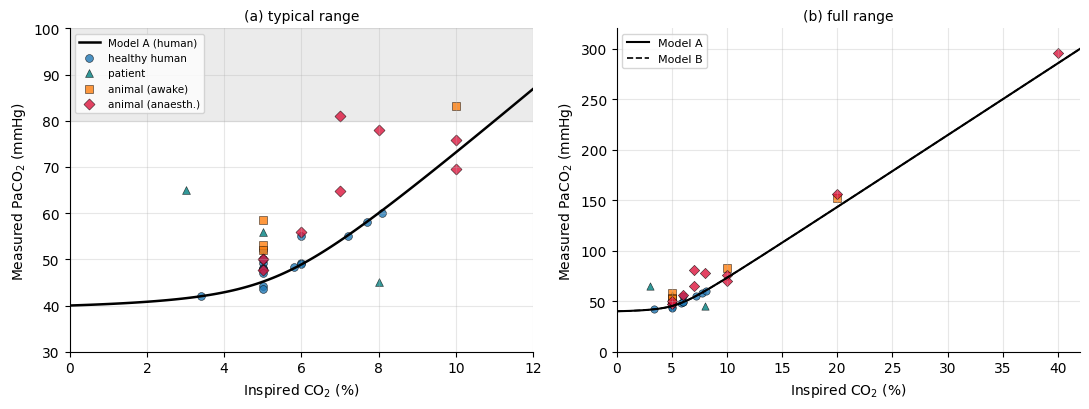

In [17]:
# Paired (inspired CO2 %, measured PaCO2 mmHg, category) from the companion review (36 challenges).
review_pairs = [
    (3, 64.9, 'patient'),
    (3.4, 42, 'human'),
    (5, 49.2, 'human'),
    (5, 48.1, 'human'),
    (5, 58.53, 'animal_awake'),
    (5, 44.2, 'human'),
    (5, 48, 'human'),
    (5, 43.6, 'human'),
    (5, 50.1, 'human'),
    (5, 48, 'human'),
    (5, 50.1, 'human'),
    (5, 47, 'human'),
    (5, 47.7, 'animal_anaes'),
    (5, 53, 'animal_awake'),
    (5, 50, 'animal_anaes'),
    (5, 52, 'animal_awake'),
    (5, 56, 'patient'),
    (5, 52, 'human'),
    (5.8, 48.4, 'human'),
    (6, 49.3, 'human'),
    (6, 55, 'human'),
    (6, 48.9, 'human'),
    (6, 56, 'animal_anaes'),
    (7, 81, 'animal_anaes'),
    (7, 64.7, 'animal_anaes'),
    (7.2, 55, 'human'),
    (7.7, 58, 'human'),
    (8, 78, 'animal_anaes'),
    (8, 45, 'patient'),
    (8.1, 60, 'human'),
    (10, 83.1, 'animal_awake'),
    (10, 75.8, 'animal_anaes'),
    (10, 69.6, 'animal_anaes'),
    (20, 156, 'animal_anaes'),
    (20, 152, 'animal_awake'),
    (40, 296, 'animal_anaes')
]
try:
    import numpy as np, matplotlib.pyplot as plt
    from fico2_paco2_converter import params_from_baseline, fico2_to_paco2, ParamsB, fico2_to_paco2_B
    pA = params_from_baseline(40.0); pB = ParamsB()
    styles = {'human': ('tab:blue','o','healthy human'), 'patient': ('teal','^','patient'),
              'animal_awake': ('tab:orange','s','animal (awake)'), 'animal_anaes': ('crimson','D','animal (anaesth.)')}
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
    g = np.linspace(0, 12, 120)
    ax1.plot(g, [fico2_to_paco2(f, pA) for f in g], 'k-', lw=1.8, label='Model A (human)')
    g2 = np.linspace(0, 42, 200)
    ax2.plot(g2, [fico2_to_paco2(f, pA) for f in g2], 'k-', lw=1.5, label='Model A')
    ax2.plot(g2, [fico2_to_paco2_B(f, pB) for f in g2], 'k--', lw=1.2, label='Model B')
    for key,(c,m,lab) in styles.items():
        pts = [(i,h) for (i,h,k) in review_pairs if k==key]
        if pts:
            xs,ys = zip(*pts)
            ax1.scatter([x for x in xs if x<=12], [h for x,h in zip(xs,ys) if x<=12],
                        c=c, marker=m, s=32, alpha=.8, edgecolor='k', lw=.4, label=lab)
            ax2.scatter(xs, ys, c=c, marker=m, s=28, alpha=.8, edgecolor='k', lw=.4)
    ax1.axhspan(80, 100, color='0.85', alpha=.5, zorder=0)
    ax1.set_xlim(0,12); ax1.set_ylim(30,100); ax1.set_title('(a) typical range', fontsize=10)
    ax2.set_xlim(0,42); ax2.set_ylim(0,320); ax2.set_title('(b) full range', fontsize=10)
    for ax in (ax1, ax2):
        ax.set_xlabel('Inspired CO$_2$ (%)'); ax.set_ylabel('Measured PaCO$_2$ (mmHg)')
        ax.grid(alpha=.3)
        for s in ('top','right'): ax.spines[s].set_visible(False)
    ax1.legend(fontsize=7.5, loc='upper left'); ax2.legend(fontsize=8, loc='upper left')
    plt.tight_layout(); plt.show()
except ImportError:
    print('matplotlib not installed - run:  pip install matplotlib numpy')

## 8. Interactive prompt

The following cell reproduces the command-line interface
(`python fico2_paco2_converter.py -i`), prompting for the direction and the required inputs.

The prompt now first asks **Model A or B**; for Model B it also asks the challenge **duration** and uses $S_{\mathrm{eff}}(t)$.

In [18]:
from fico2_paco2_converter import interactive
interactive()

 FiCO2 <-> PaCO2 converter
 Which model?
   A) steady state   -- response fully developed; closed form (default S=2.69)
   B) time-resolved  -- you also give the challenge DURATION; uses S_eff(t)=phi(t)*S


## 9. Assumptions and limitations

- Ideal alveolar–arterial equilibration, $P_aCO_2 \approx P_ACO_2 \approx P_{ET}CO_2$, i.e.
  healthy lungs without appreciable ventilation–perfusion mismatch or shunt (Riley &
  Cournand, 1949; Slessarev et al., 2007).
- A linear hypercapnic ventilatory response over the working range ≈ 40–80 mmHg (Read, 1967;
  West, 2012).
- A single population-mean slope $S = 2.69$, which will not match any individual and varies
  with age, sex and body size (Patrick & Howard, 1972; Aitken et al., 1986).
- Published slopes are typically minute-ventilation slopes ($\Delta \dot V_E / \Delta P_aCO_2$);
  they are used here for the alveolar slope, valid while dead-space ventilation changes little.
- The resting alveolar ventilation ($\dot V_A \approx 4.2$ L·min⁻¹) is built from textbook
  values for tidal volume (500 mL), anatomic dead space (150 mL) and frequency (12 min⁻¹)
  (West & Luks, 2021); all three vary appreciably between individuals and with breathing
  pattern, shifting $\dot V_{A,\text{base}}$ and hence the baseline anchoring.

The method is a deterministic first-order approximation, intended to harmonise reported
CO₂-challenge magnitudes across studies rather than to predict an individual subject's
arterial tension.

## References
*(all held in the Zotero library — CO2 Ventilation collection)*

1. Dalton, J. (1802). *Experimental Essays on the Constitution of Mixed Gases.* Memoirs of the
   Literary and Philosophical Society of Manchester, 5, 535–602.
2. Haldane, J. S., & Priestley, J. G. (1905). The regulation of the lung-ventilation.
   *The Journal of Physiology, 32*(3–4), 225–266. https://doi.org/10.1113/jphysiol.1905.sp001081
3. Riley, R. L., & Cournand, A. (1949). Ideal alveolar air and the analysis of
   ventilation-perfusion relationships in the lungs. *Journal of Applied Physiology, 1*(12),
   825–847. https://doi.org/10.1152/jappl.1949.1.12.825
4. Nielsen, M., & Smith, H. (1952). Studies on the regulation of respiration in acute hypoxia.
   *Acta Physiologica Scandinavica, 24*(4), 293–313.
   https://doi.org/10.1111/j.1748-1716.1952.tb00847.x
5. Schaefer, K. E. (1958). Respiratory pattern and respiratory response to CO₂.
   *Journal of Applied Physiology, 13*(1), 1–14. https://doi.org/10.1152/jappl.1958.13.1.1
6. Read, D. J. C. (1967). A clinical method for assessing the ventilatory response to carbon
   dioxide. *Australasian Annals of Medicine, 16*(1), 20–32.
   https://doi.org/10.1111/imj.1967.16.1.20
7. Patrick, J. M., & Howard, A. (1972). The influence of age, sex, body size and lung size on
   the control and pattern of breathing during CO₂ inhalation in Caucasians.
   *Respiration Physiology, 16*(3), 337–350. https://doi.org/10.1016/0034-5687(72)90063-1
8. Gelfand, R., & Lambertsen, C. J. (1973). Dynamic respiratory response to abrupt change of
   inspired CO₂ at normal and high PO₂. *Journal of Applied Physiology, 35*(6), 903–913.
   https://doi.org/10.1152/jappl.1973.35.6.903
9. Hirshman, C. A., McCullough, R. E., & Weil, J. V. (1975). Normal values for hypoxic and
   hypercapnic ventilatory drives in man. *Journal of Applied Physiology, 38*(6), 1095–1098.
   https://doi.org/10.1152/jappl.1975.38.6.1095
10. Bellville, J. W., Whipp, B. J., Kaufman, R. D., Swanson, G. D., Aqleh, K. A., & Wiberg, D. M.
    (1979). Central and peripheral chemoreflex loop gain in normal and carotid body-resected
    subjects. *Journal of Applied Physiology, 46*(4), 843–853.
    https://doi.org/10.1152/jappl.1979.46.4.843
11. Aitken, M. L., Franklin, J. L., Pierson, D. J., & Schoene, R. B. (1986). Influence of body
    size and gender on control of ventilation. *Journal of Applied Physiology, 60*(6),
    1894–1899. https://doi.org/10.1152/jappl.1986.60.6.1894
12. Khamnei, S., & Robbins, P. A. (1990). Hypoxic depression of ventilation in humans:
    alternative models for the chemoreflexes. *Respiration Physiology, 81*(1), 117–134.
    https://doi.org/10.1016/0034-5687(90)90074-9
13. Mohan, R., & Duffin, J. (1997). The effect of hypoxia on the ventilatory response to carbon
    dioxide in man. *Respiration Physiology, 108*(2), 101–115.
    https://doi.org/10.1016/S0034-5687(97)00024-8
14. Tansley, J. G., Pedersen, M. E. F., Clar, C., & Robbins, P. A. (1998). Human ventilatory
    response to 8 h of euoxic hypercapnia. *Journal of Applied Physiology, 84*(2), 431–434.
    https://doi.org/10.1152/jappl.1998.84.2.431
15. Pedersen, M. E. F., Fatemian, M., & Robbins, P. A. (1999). Identification of fast and slow
    ventilatory responses to carbon dioxide under hypoxic and hyperoxic conditions in humans.
    *The Journal of Physiology, 521*(1), 273–287.
    https://doi.org/10.1111/j.1469-7793.1999.00273.x
16. Cruickshank, S., & Hirschauer, N. (2004). The alveolar gas equation. *Continuing Education
    in Anaesthesia Critical Care & Pain, 4*(1), 24–27. https://doi.org/10.1093/bjaceaccp/mkh008
17. Slessarev, M., Han, J., Mardimae, A., Prisman, E., Preiss, D., Volgyesi, G., Ansel, C.,
    Duffin, J., & Fisher, J. A. (2007). Prospective targeting and control of end-tidal CO₂ and
    O₂ concentrations. *The Journal of Physiology, 581*(3), 1207–1219.
    https://doi.org/10.1113/jphysiol.2007.129395
18. West, J. B. (2012). *Respiratory Physiology: The Essentials* (9th ed.). Lippincott Williams
    & Wilkins.
19. Lumb, A. B., & Thomas, C. R. (2020). *Nunn's Applied Respiratory Physiology* (9th ed.).
    Elsevier.
20. West, J. B., & Luks, A. M. (2021). *West's Respiratory Physiology: The Essentials* (11th
    ed.). Wolters Kluwer.
21. Lambertsen, C. J. (1971). Therapeutic gases: oxygen, carbon dioxide and helium. In J. R.
    Di Palma (Ed.), *Drill's Pharmacology in Medicine* (4th ed., Ch. 55). McGraw-Hill.
22. Guais, A., Brand, G., Jacquot, L., et al. (2011). Toxicity of carbon dioxide: a review.
    *Chemical Research in Toxicology, 24*(12), 2061–2070. https://doi.org/10.1021/tx200220r
23. Swanson, G. D., & Bellville, J. W. (1975). Step changes in end-tidal CO₂: methods and
    implications. *J Appl Physiol, 39*(3), 377–385. https://doi.org/10.1152/jappl.1975.39.3.377
24. Cunningham, D. J. C., Robbins, P. A., & Wolff, C. B. (1986). Integration of respiratory responses
    to changes in alveolar PCO₂, PO₂ and arterial pH. In *Handbook of Physiology, Sect. 3, Vol. II*.
25. Dahan, A., DeGoede, J., Berkenbosch, A., & Olievier, I. C. W. (1990). The influence of oxygen on the
    ventilatory response to CO₂ in man. *J Physiol, 428*, 485–499. https://doi.org/10.1113/jphysiol.1990.sp018223